In [1]:
import os

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, LlamaTokenizer, LlamaForCausalLM, BitsAndBytesConfig
import pandas as pd
import re
import numpy as np
from src._utils._helpers import log_synthetic_data, response2json, get_response, set_seed, clear_cuda_cache, get_context_examples

HF_TOKEN = open("src/_utils/hf_token.txt","r").read() # your huggingface token

In [2]:
# Create the folder to save the synthetic data
folder_name = "synthetic_data/logs"
os.makedirs(folder_name, exist_ok=True)

# file where the logs will be saved
log_file_path = folder_name + "/agnews_log.json"
RECREATE_LOG = False
if os.path.exists(log_file_path) and RECREATE_LOG:
    os.remove(log_file_path) # recreate from scratch

# DEVICE
device = 'cuda:0'
model = None

# DATA
df = pd.read_csv("real_data/train/agnewstrainAll.csv")
df = df.rename(columns={"2": "text", "3": "label"})
display(df.head())

labels_lst = df['label'].unique()
labels_str = ", ".join(labels_lst)
labels_str_bullet = "\n".join([f"- {name}" for name in labels_lst])
labels_str_bullet_bold = "\n".join([f"- **{name}**" for name in labels_lst])
print(f"Labels: {labels_str}")

# Print the first example for each label
examples = []
for label in labels_lst:
    example = (df[df['label'] == label].iloc[0]).loc['text']
    examples.append(example)
    print(f"Label: {label}\nText: {example}\n")

,0,1,text,label
0,1000_train,Hartford executive #39;s stock sale probed,New York AG is investigating the timing of a s...,Business
1,1001_train,Cool Batman Photo!,"In related news, it was announced yesterday th...",Sci/Tech
2,1002_train,Stocky Monkey in Himalayas Becomes Newest Prim...,Scientists from India working in the Himalayas...,Sci/Tech
3,1003_train,"Bush, Kerry Don''t Worry About Tech","Election Day is less than two weeks away, but ...",Sci/Tech
4,1004_train,The Teeming Crowd in Video Games,"Jeffrey Griffiths, the president and chief exe...",Sci/Tech


Labels: Business, Sci/Tech, Sports, World
Label: Business
Text: New York AG is investigating the timing of a sale by Thomas Marra; company reports higher 3Q. NEW YORK (Reuters) - The Hartford Financial Services Group Inc.

Label: Sci/Tech
Text: In related news, it was announced yesterday that Warner Bros. Interactive Entertainment, DC Comics and Electronic Arts will bring a Batman Begins videogame tie-in.

Label: Sports
Text: Lindsay Davenport #39;s world number one ranking is in doubt after she failed to make the finals of the WTA Tour Championships in Los Angeles.

Label: World
Text:  JERUSALEM (Reuters) - Israeli Prime Minister Ariel Sharon  accused far-rightists Sunday of trying to incite civil war over  his plan to withdraw from the occupied Gaza Strip and called  for measures to curb such groups.



In [3]:
clear_cuda_cache(model)

model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map=device,
    attn_implementation='flash_attention_2',
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model.generation_config.pad_token_id = tokenizer.pad_token_id

In [4]:
messages = [{"role": "user", "content": "OUR PROMPT"}]
tokenizer.apply_chat_template(
            [{"role": "user", "content": "OUR PROMPT"}],
            tokenize=False,
            add_generation_prompt=True,
        )

'<｜begin▁of▁sentence｜><｜User｜>OUR PROMPT<｜Assistant｜><think>\n'

---

In [5]:
clear_cuda_cache(model)

quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
model_name = "meta-llama/Llama-2-7b-chat-hf"
model = LlamaForCausalLM.from_pretrained(
            model_name, 
            token=HF_TOKEN,
            torch_dtype=torch.float16,
            attn_implementation='flash_attention_2',
            quantization_config=quantization_config,
            low_cpu_mem_usage=True
        ).to("cuda")

tokenizer = LlamaTokenizer.from_pretrained(model_name, token=HF_TOKEN)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [6]:
system = "You are an expert in journalism and NLP specializing in news classification."
prompt = f"""\
Your task is to generate one high-quality short document (around 30 words), that talks about one of the following four News categories:  
{labels_str_bullet}

Choose one of the categories (labels), generate the corresponding text and return it in the following JSON format:

```json
{{
    "text": "<text of the document>", 
    "label": "<corresponding label>", 
}}
```
"""
assistant_response = "Of course! I'm happy to help. Please provide me with the category you would like me to focus on, and I will generate a high-quality short document for you."
messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": prompt},
    ]

response, delta_t = get_response("", model, tokenizer, messages=messages, apply_chat_template=True, max_new_tokens=1024)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "baseline", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 5.34 seconds
GENERATED RESPONSE:
 Of course! I'm happy to help. Please let me know which category you would like the document to be in, and I will generate a high-quality short document for you.

Here are the four categories to choose from:

* Business: Discusses news related to the global economy, entrepreneurship, and the world of work.
* Sci/Tech: Covers news related to science, technology, and their impact on society.
* Sports: Reports on the latest news and developments in the world of sports, including professional and amateur leagues, tournaments, and events.
* World: Focuses on news related to international relations, geopolitics, and global events that affect the world at large.

Please let me know which category you would like the document to be in, and I will generate the text for you.
No JSON-like content found in the response.
No samples to log.


In [9]:
# <s>[INST] <<SYS>>
# {{ system_prompt }}
# <</SYS>>
# 
# {{ user_msg_1 }} [/INST] {{ model_answer_1 }} </s><s>[INST] {{ user_msg_2 }} [/INST]

random_label = df.sample(n=1, random_state=42).to_dict(orient="records")[0]['label']
print(f"Random label: {random_label}")
system = "You are an expert in journalism and NLP specializing in news classification."
prompt = f"""\
Your task is to generate one high-quality short document (around 30 words), that talks about one of the following four News categories:  
{labels_str_bullet}

Choose one of the categories (labels), generate the corresponding text and return it in the following JSON format:

```json
{{
    "text": "<text of the document>", 
    "label": "<corresponding label>", 
}}
```
"""
assistant_response = "Of course! I'm happy to help. Please provide me with the category you would like me to focus on, and I will generate a high-quality short document for you."
messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": prompt},
    {"role": "assistant", "content": assistant_response},
    {"role": "user", "content": f"label: {random_label}"},
    ]

# response, delta_t = get_response("", model, tokenizer, messages=messages, apply_chat_template=True, max_new_tokens=1024)
# synthetic_data = response2json(response)
# log_synthetic_data(model_name, "baseline", prompt, synthetic_data, delta_t, output_file=log_file_path)

print(tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        ))

Random label: Sci/Tech
<s>[INST] <<SYS>>
You are an expert in journalism and NLP specializing in news classification.
<</SYS>>

Your task is to generate one high-quality short document (around 30 words), that talks about one of the following four News categories:  
- Business
- Sci/Tech
- Sports
- World

Choose one of the categories (labels), generate the corresponding text and return it in the following JSON format:

```json
{
    "text": "<text of the document>", 
    "label": "<corresponding label>", 
}
``` [/INST] Of course! I'm happy to help. Please provide me with the category you would like me to focus on, and I will generate a high-quality short document for you. </s><s>[INST] label: Sci/Tech [/INST]


In [ ]:
messages = [{"role": "system", "content": "ACT LIKE..."},
            {"role": "user", "content": "OUR PROMPT"},
            {"role": "assistant", "content": "CHOOSE LABEL"},
            {"role": "user", "content": "label: RANDOM_LABEL"}]

print(tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
))

<s>[INST] <<SYS>>
ACT LIKE...
<</SYS>>

OUR PROMPT [/INST] CHOOSE LABEL </s><s>[INST] label: RANDOM_LABEL [/INST]


---

In [2]:
import os
import re

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise

import pandas as pd
from src._utils._helpers import get_generated_examples_df
from src._utils._data_analysis_helpers import basic_analysis, check_patterns
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)  # Set context for larger fonts

analysis_result = []

DATASET = "agnews"
SYN_DATA_DIR = "synthetic_data/datasets/DeepSeek-R1-Distill-Qwen-1.5B/"

In [3]:
df_real = pd.read_csv("real_data/train/"+DATASET+"trainAll.csv")
df_real = df_real.rename(columns={"2": "text", "3": "label"})

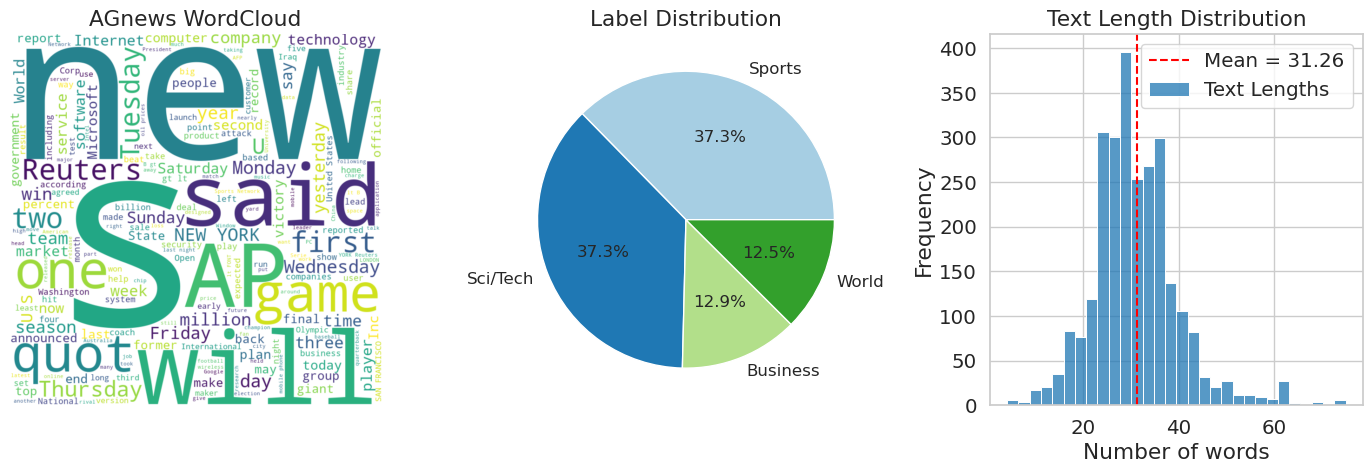

Number of train samples: 2679
Set of labels: {'Sports', 'Business', 'Sci/Tech', 'World'}
Number of labels: 4


In [29]:
def basic_analysis(df, print_missing_values=True, print_count_statistics=True):
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    # ---- 1️ WordCloud ----
    text_corpus = " ".join(str(text) for text in df["text"])
    wordcloud = WordCloud(
        width=800, height=800, background_color="white", colormap="viridis"
    ).generate(text_corpus)
    axes[0].imshow(wordcloud, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title("AGnews WordCloud")

    # ---- 2️ Pie Chart for Label Distribution ----
    label_counts = df["label"].value_counts()

    # Reduce label size if too many labels
    if len(label_counts) >= 10:
        label_fontsize = 8
    else:
        label_fontsize = 12
    axes[1].pie(
        label_counts,
        labels=label_counts.index,
        autopct="%1.1f%%",
        colors=plt.cm.Paired.colors,
        textprops={"fontsize": label_fontsize},
    )
    axes[1].set_title("Label Distribution")

    # ---- 3️ Text Length Distribution ----
    df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))  # Count words
    # Filter the dataset (just for visualization purposes)
    threshold = df["text_length"].quantile(0.995)  # Keep 99.5% of data
    filtered_df = df[df["text_length"] <= threshold]

    mean_length = df["text_length"].mean()

    sns.histplot(
        filtered_df["text_length"], bins=30, kde=False, ax=axes[2], label="Text Lengths"
    )
    axes[2].axvline(
        mean_length, color="red", linestyle="--", label=f"Mean = {mean_length:.2f}"
    )
    axes[2].set_title("Text Length Distribution")
    axes[2].set_xlabel("Number of words")
    axes[2].set_ylabel("Frequency")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # ---- Print basic statistics ----
    print(f"Number of train samples: {len(df)}")
    print(f"Set of labels: {set(df['label'])}")
    print(f"Number of labels: {len(set(df['label']))}")
    if print_missing_values:
        print(f"Missing Values: \n{df.isnull().sum()}", sep="")
    if print_count_statistics:
        print("\nWord Count Statistics:")
        print(df["text_length"].describe().round(2))

    return None


basic_analysis(df_real, print_count_statistics=False, print_missing_values=False)

---

In [25]:
import matplotlib.lines as mlines
def plot_f1_generationMethod(df, x_col="synthetic_ratio", hue_col="generation_method"):
    df_long = df.melt(
        id_vars=[x_col, hue_col],
        value_vars=["micro-f1", "macro-f1"],
        var_name="metric",
        value_name="score",
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    cmap = sns.color_palette("tab10")
    palette = {
        #'real': 'red', # cmap[3]
        "generic": cmap[0],
        "targeted": cmap[1],
        "unsupContext": cmap[2],
        "zeroshotLabels": cmap[4],
    }
    markers = {
        #'real': '*',
        "generic": "X",
        "targeted": "s",
        "unsupContext": "P",
        "zeroshotLabels": "D",
    }

    solid_dashes = {k: "" for k in df_long[hue_col].unique()}
    for ax, metric in zip(axes, df_long["metric"].unique()):
        # Exclude 'real' from the plot
        df_metric = df_long[
            (df_long["metric"] == metric) & (df_long[hue_col] != "real")
        ]

        sns.lineplot(
            data=df_metric,
            x=x_col,
            y="score",
            hue=hue_col,
            style=hue_col,
            dashes=solid_dashes,
            markers=markers,
            palette=palette,
            ax=ax,
            linewidth=2,
            markersize=10,
            legend=False,
        )

        # Add horizontal real-only line
        real_score = df_long[
            (df_long[hue_col] == "real") & (df_long["metric"] == metric)
        ]["score"].values[0]
        ax.axhline(
            y=real_score, linestyle="--", color=cmap[3], linewidth=2, alpha=1, zorder=0
        )

        ax.set_title(metric)
        ax.set_xlabel(x_col.replace("_", " ").title())
        ax.set_ylabel("Score")
        ax.grid(True, which='major', axis='both', alpha=0.5)

    custom_lines = [
        mlines.Line2D(
            [],
            [],
            color=palette[k],
            marker=markers[k],
            linestyle="-",
            markersize=10,
            label=k,
        )
        for k in df_long[hue_col].unique()
        if k != "real"
    ]
    # custom_lines.append(
    #     mlines.Line2D([], [], color='red', marker='*', linestyle='None', markersize=15, label='real')
    # )
    custom_lines.append(
        mlines.Line2D(
            [], [], color=cmap[3], linestyle="--", linewidth=2, label=r"100% real"
        )
    )

    fig.legend(
        handles=custom_lines,
        title=hue_col.replace("_", " ").title(),
        loc='lower center',
        bbox_to_anchor=(0.5, -0.0),
        ncol=len(custom_lines),
        frameon=False
    )
    plt.tight_layout(rect=[0, 0.1, 1, 1])

    plt.show()

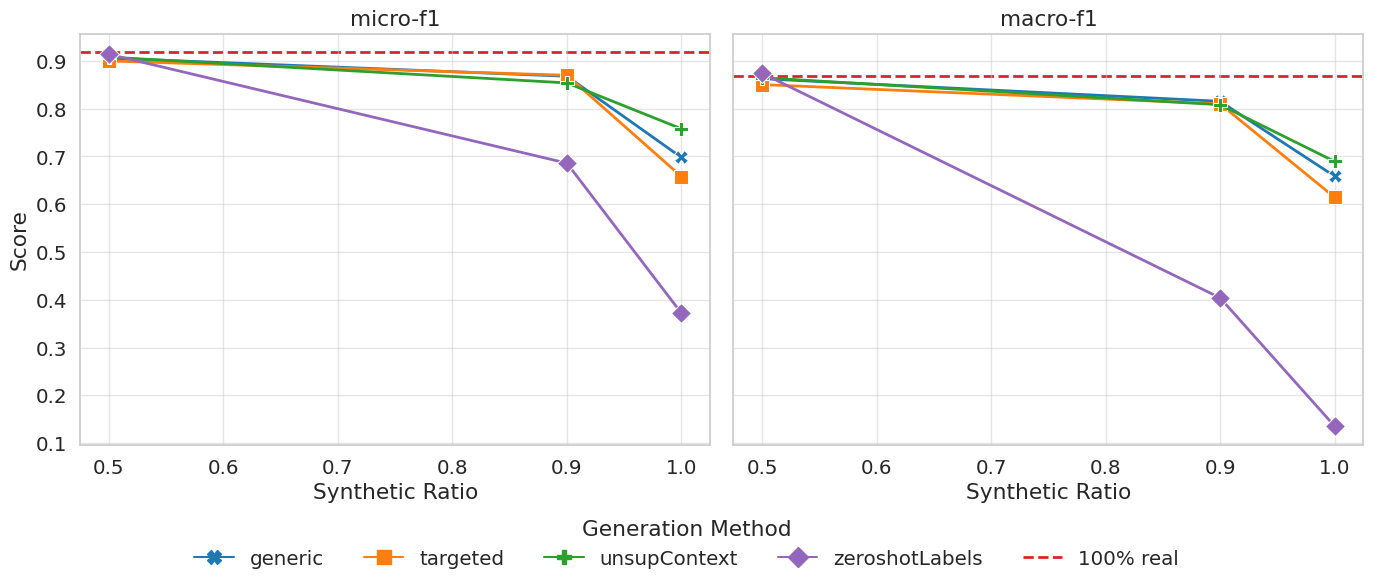

In [26]:
LLM_NAME = "DeepSeek-R1-Distill-Qwen-1.5B"
DATASET_NAME = "agnews"
FOLDER_DIR = "src/"+DATASET_NAME+"/experiments/RoBERTA_500samples/data_"+LLM_NAME
df_results = pd.read_csv(os.path.join(FOLDER_DIR, "RoBERTA_results_dev.csv"))

plot_f1_generationMethod(df=df_results, x_col="synthetic_ratio", hue_col="generation_method")

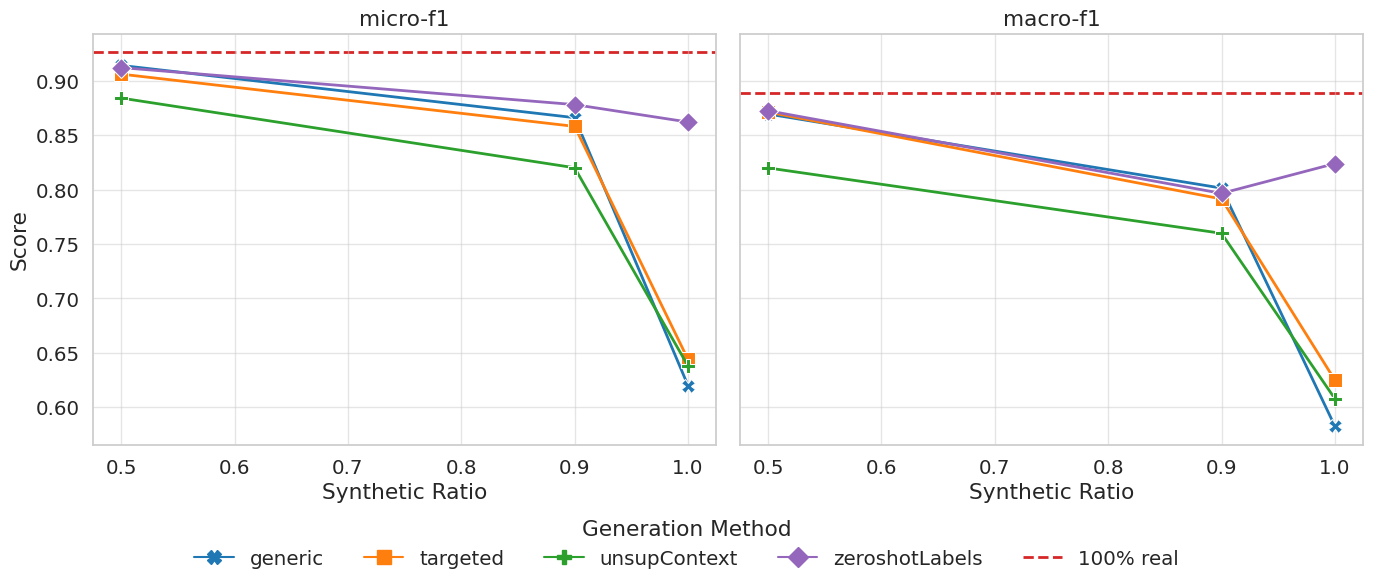

In [27]:
LLM_NAME = "Llama-2-7b-chat-hf"
FOLDER_DIR = "src/"+DATASET_NAME+"/experiments/RoBERTA_500samples/data_"+LLM_NAME
df_results = pd.read_csv(os.path.join(FOLDER_DIR, "RoBERTA_results_dev.csv"))

plot_f1_generationMethod(df=df_results, x_col="synthetic_ratio", hue_col="generation_method")

---


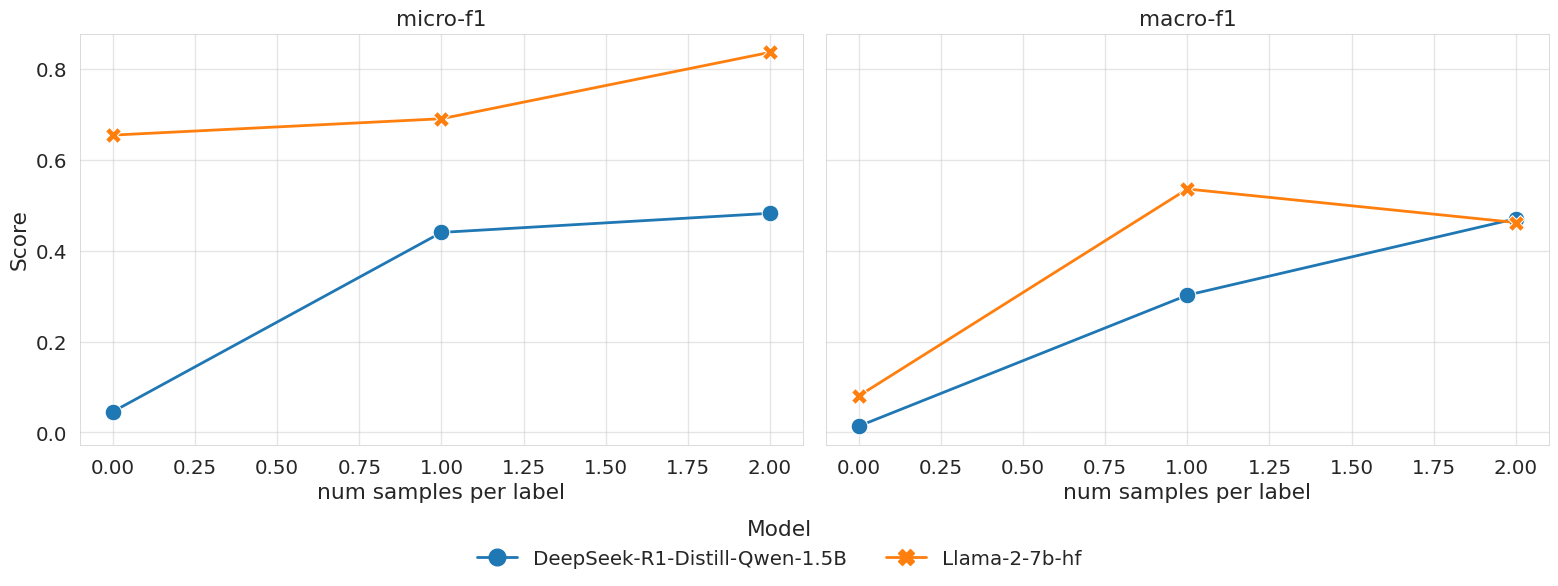

In [24]:
FOLDER_DIR = "src/"+DATASET_NAME+"/experiments/fewshotCasualLM_500samples"
df_results = pd.read_csv(os.path.join(FOLDER_DIR, "fewshotCasualLM_results_dev.csv"))
df_results["n_samples_per_label"] = df_results["method"].map({
    "zeroshot": 0,
    "1ex4label": 1,
    "2ex4label": 2
})
df_results = df_results.rename(columns={
    "f1_micro": "micro-f1",
    "f1_macro": "macro-f1",
})

def plot_f1_lineplot(df, x_col="synthetic_ratio", hue_col="generation_method"):
    df_long = df.melt(
        id_vars=[x_col, hue_col],
        value_vars=["micro-f1", "macro-f1"],
        var_name="metric",
        value_name="score",
    )

    # Build relplot
    g = sns.relplot(
        data=df_long,
        x=x_col,
        y="score",
        col="metric",
        hue=hue_col,
        style=hue_col,
        kind="line",
        markers=True,
        dashes=False,
        height=6,
        aspect=1,
        facet_kws={"sharey": True},
    )

    # Adjust marker size and line width
    for ax in g.axes.flat:
        for line in ax.lines:
            line.set_markersize(12)  # marker size
            line.set_linewidth(2)  # line width
        
        # Add grid lines to all sides
        ax.grid(True, which='major', axis='both', alpha=0.5)
        ax.set_axisbelow(True)
        
        # Make sure all spines are visible
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)

    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("num samples per label", "Score")

    # Remove the default legend and create a custom one below
    if g._legend:
        g._legend.remove()
    
    # Get legend handles and labels
    handles, labels = g.axes[0, 0].get_legend_handles_labels()
    
    # Create custom legend below the plots
    g.fig.legend(
        handles=handles,
        labels=labels,
        title=hue_col.replace("_", " ").title(),
        loc='lower center',
        bbox_to_anchor=(0.5, -0.0),
        ncol=len(labels),
        frameon=False
    )
    
    plt.tight_layout(rect=[0, 0.1, 1, 1])

    # for ax in g.axes.flat:
    #     ax.set_ylim(0, 1.05)

    plt.show()

plot_f1_lineplot(df=df_results, x_col="n_samples_per_label", hue_col="model")